# Evaluating the results

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Dict
from matplotlib.figure import Figure

allowed_tokens = ['A', 'B', 'C', 'D', 
                  'AB', 'AC', 'AD', 'BC', 'BD', 'CD',
                  'ABC', 'ABD', 'BCD',
                  'ABCD']

In [2]:
def plot_allowed_token_histogram_multi(
    dfs: Dict[str, pd.DataFrame],
    allowed_tokens: List[str],
    title: str | None = None
) -> Figure:
    experiment_names = list(dfs.keys())
    n_experiments = len(experiment_names)
    n_tokens = len(allowed_tokens)

    all_counts = {}

    for experiment_name, df in dfs.items():
        dcpm_cols = df.filter(like="DCPMI")

        if dcpm_cols.empty:
            all_counts[experiment_name] = pd.Series(
                0, index=allowed_tokens
            )
            continue

        tmp = df.copy()
        tmp["Max DCPMI Name"] = dcpm_cols.idxmax(axis=1)
        tmp["Max Token"] = tmp["Max DCPMI Name"].astype(str).str.split().str[0]
        counts = tmp["Max Token"].value_counts()
        counts = counts.reindex(allowed_tokens, fill_value=0)

        all_counts[experiment_name] = counts

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(n_tokens)
    bar_width = 0.8 / n_experiments

    for i, (experiment_name, counts) in enumerate(all_counts.items()):
        offset = (i - n_experiments / 2) * bar_width + bar_width / 2
        bars = ax.bar(
            x + offset,
            counts.values,
            bar_width,
            label=experiment_name
        )
        for bar, value in zip(bars, counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                str(int(value)),
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels(allowed_tokens, rotation=45, ha="right")
    ax.set_xlabel("Allowed Tokens")
    ax.set_ylabel("Number of occurences")
    ax.set_title(title or "Allowed Token Occurrences Across Experiments")
    ax.legend(title="Experiment")
    ax.set_ylim(0, 100)

    fig.tight_layout()
    return fig

## Load the results

C:\Users\Miro\AppData\Local\Temp\ipykernel_25480\2602030084.py:22: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  tmp["Max DCPMI Name"] = dcpm_cols.idxmax(axis=1)
C:\Users\Miro\AppData\Local\Temp\ipykernel_25480\2602030084.py:22: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  tmp["Max DCPMI Name"] = dcpm_cols.idxmax(axis=1)
C:\Users\Miro\AppData\Local\Temp\ipykernel_25480\2602030084.py:22: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  tmp["Max DCPMI Name"] = dcpm_cols.idxmax(axis=1)
C:\Users\Miro\AppData\Local\Temp\ipykernel_25480\2602030084.py:22: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprec

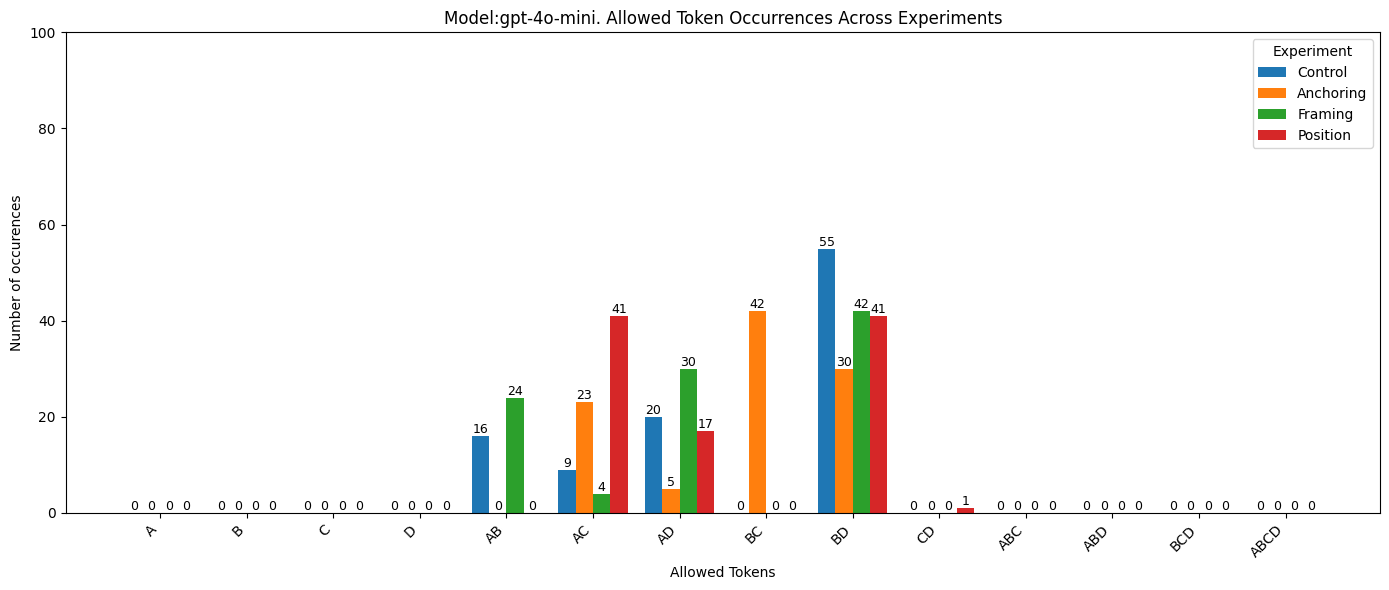

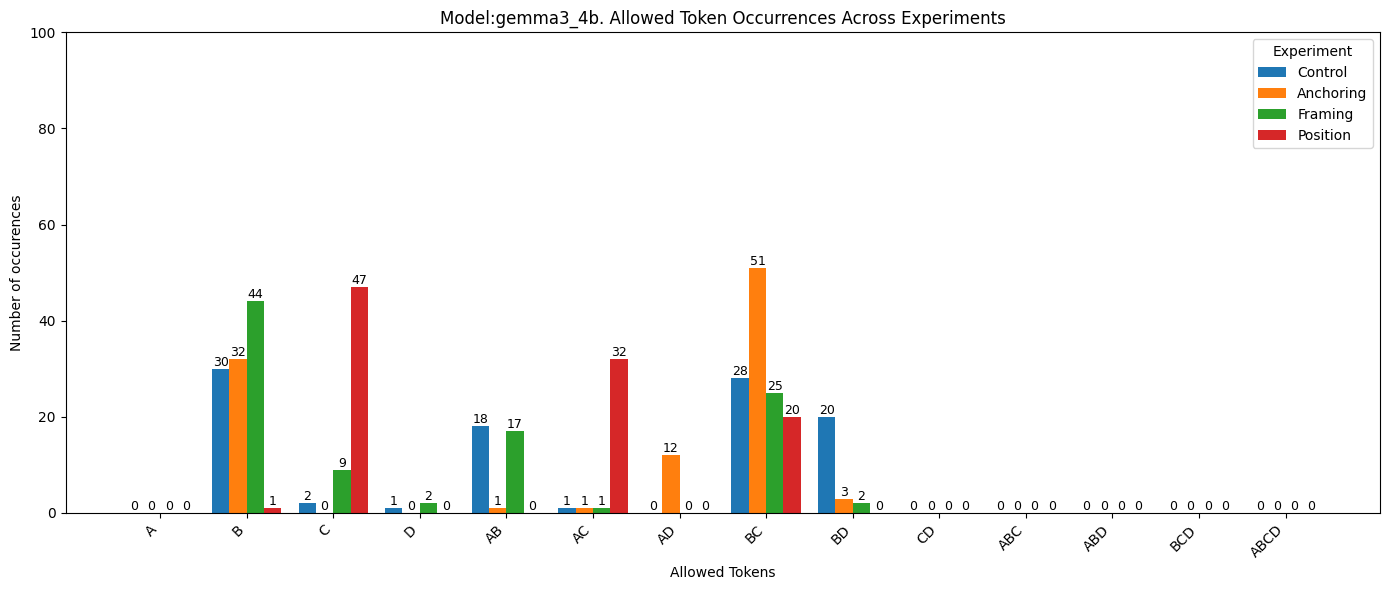

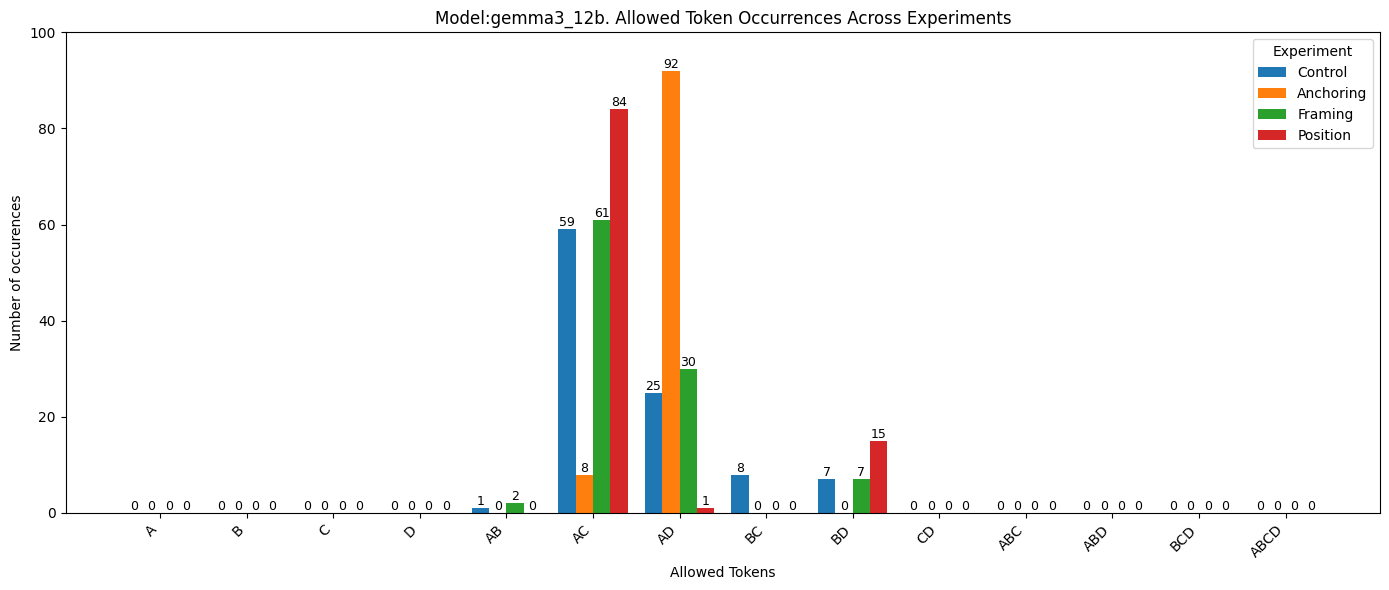

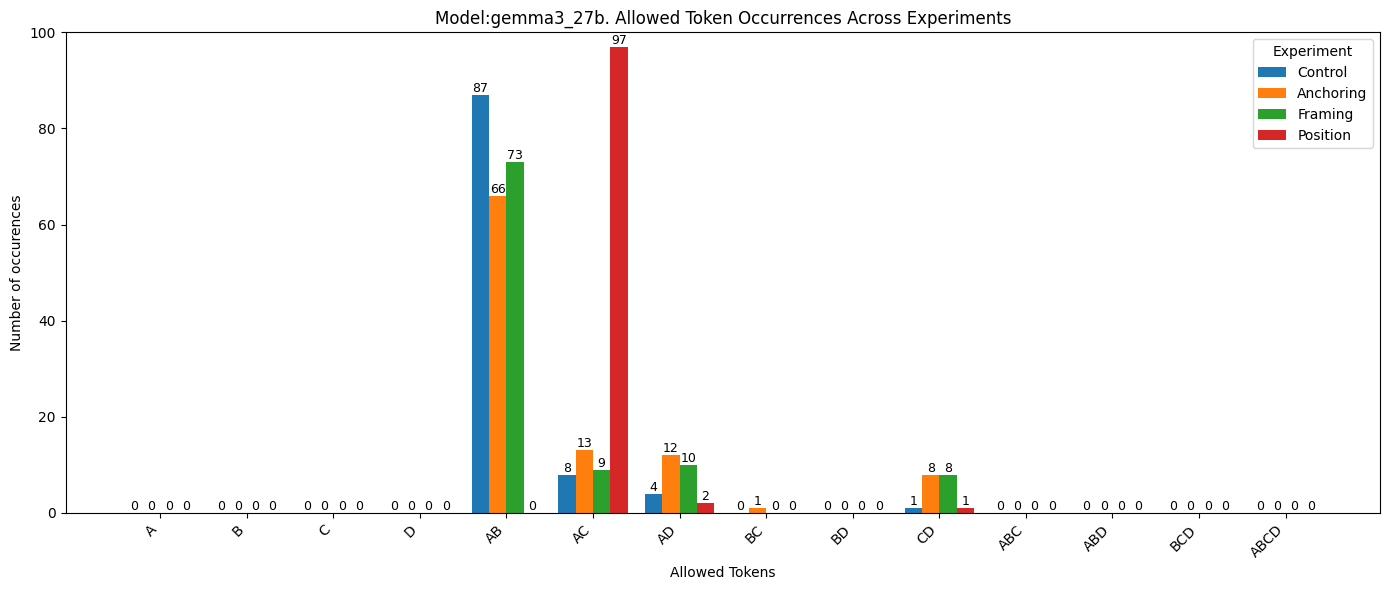

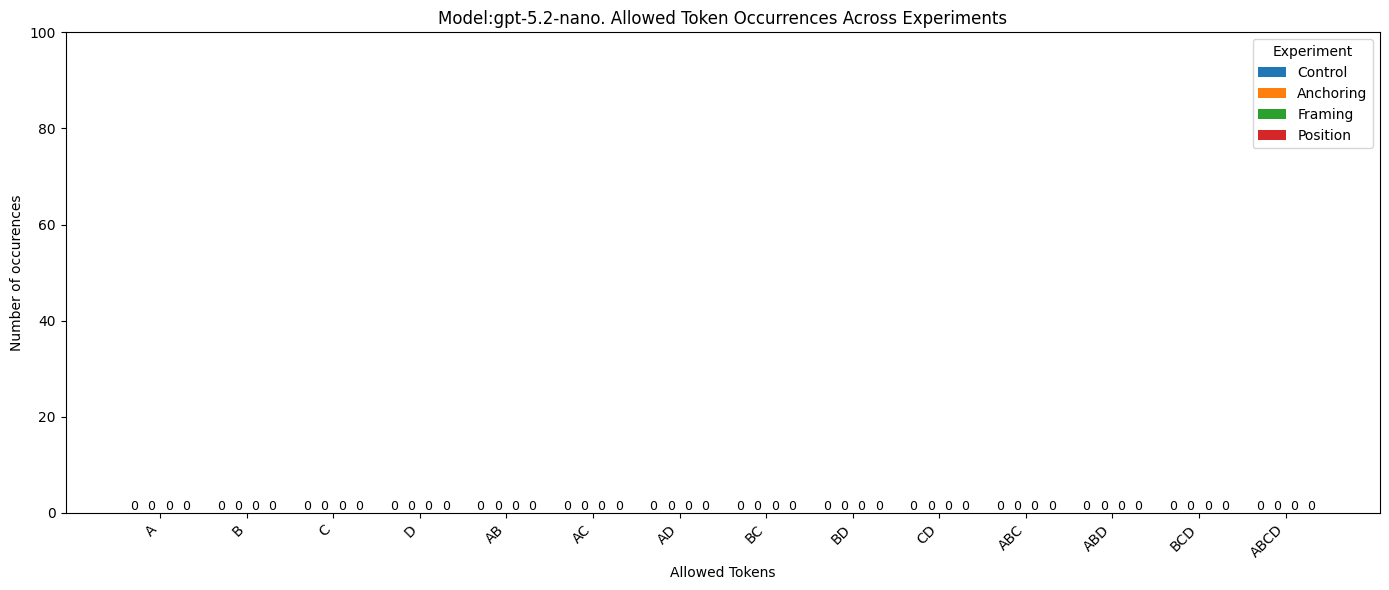

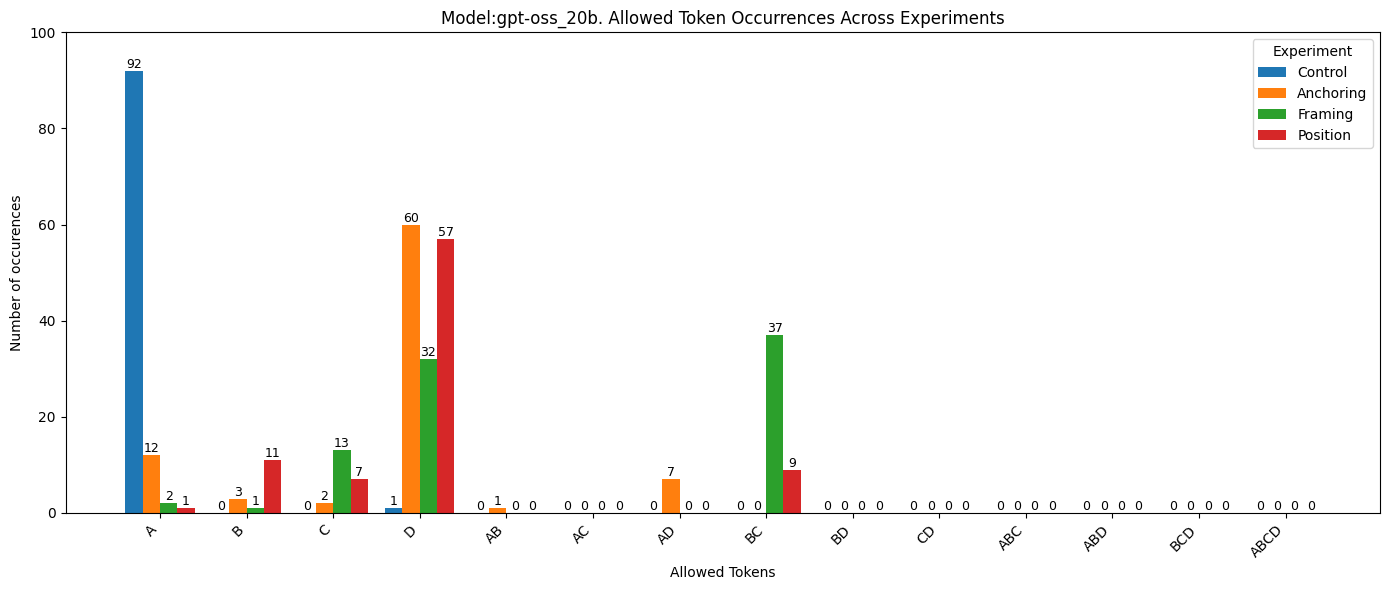

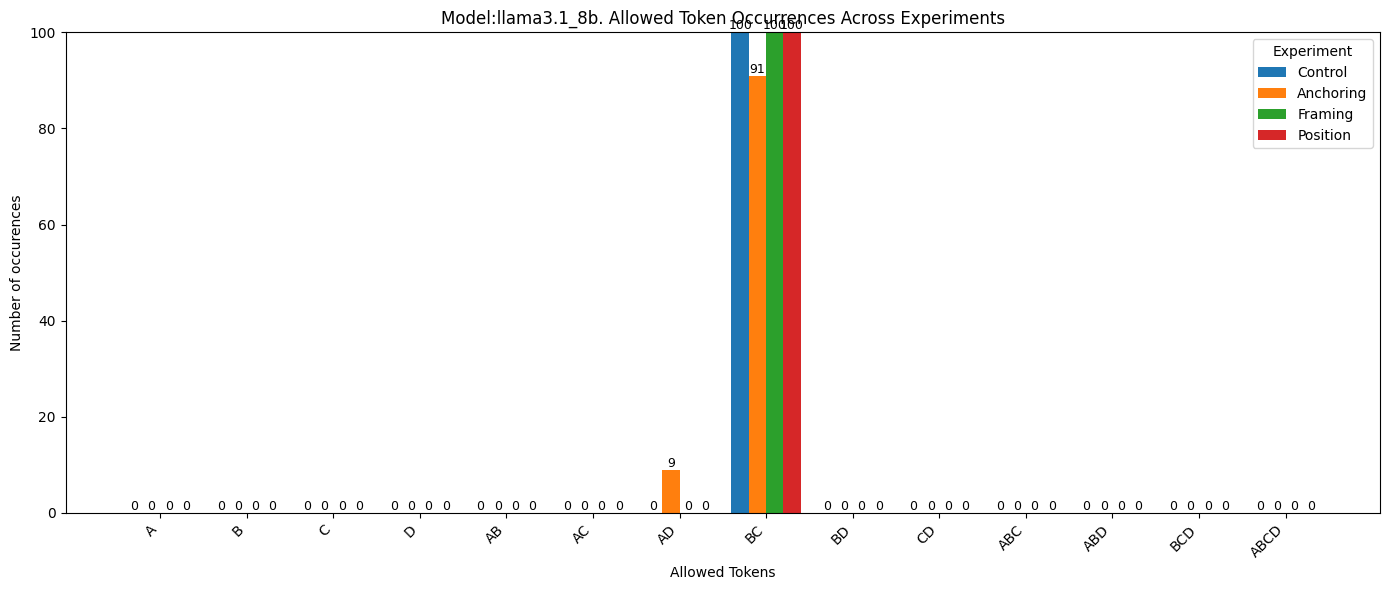

In [3]:
fig_results = {}
models_names = [
    'gpt-4o-mini', 'gemma3_4b','gemma3_12b','gemma3_27b', 'gpt-5.2-nano', 'gpt-oss_20b', 'llama3.1_8b'
]

for model_name in models_names:
    logs_dfs_dict = {
        'Control': pd.read_csv(f'../logs/{model_name}_control_wason_study_results.csv'),
        'Anchoring': pd.read_csv(f'../logs/{model_name}_anchoring_wason_study_results.csv'),
        'Framing': pd.read_csv(f'../logs/{model_name}_framing_wason_study_results.csv'),
        'Position': pd.read_csv(f'../logs/{model_name}_position_wason_study_results.csv'),
    }

    fig = plot_allowed_token_histogram_multi(
        dfs=logs_dfs_dict,
        allowed_tokens=allowed_tokens,
        title= f"Model:{model_name}. Allowed Token Occurrences Across Experiments"
    )

    fig_results[model_name] = fig



In [4]:
plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)


    # Save figure
for model_name, fig in fig_results.items():
    output_path = os.path.join(
        plots_dir,
        f"{model_name}_allowed_token_histogram.png"
    )
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    fig.clf()
    plt.show(fig)